Iniciando os testes de benchmark...
n =   16 | Tempo = 0.000184 segundos
n =   32 | Tempo = 0.000068 segundos
n =   64 | Tempo = 0.000080 segundos
n =  128 | Tempo = 0.000261 segundos
n =  256 | Tempo = 0.001493 segundos
n =  512 | Tempo = 0.007453 segundos
n = 1024 | Tempo = 0.035531 segundos
n = 2048 | Tempo = 0.241026 segundos


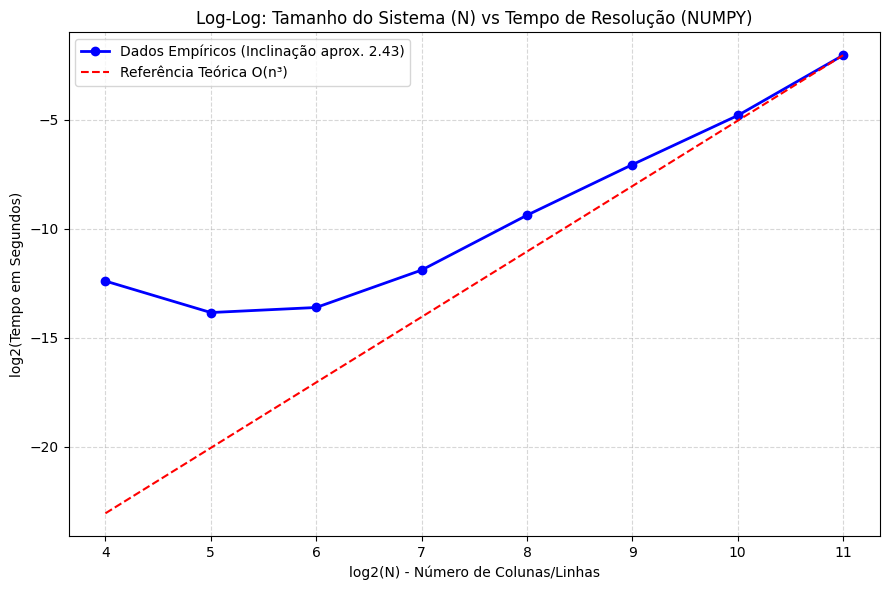


Estimativa empírica da complexidade: O(n^2.43)


In [2]:
import numpy as np
import time
import matplotlib.pyplot as plt

# Valores de n (tamanho das matrizes n x n)
n_values = [16, 32, 64, 128, 256, 512, 1024, 2048]
times = []

print("Iniciando os testes de benchmark...")

for n in n_values:
    # Cria uma matriz A e um vetor b com valores aleatórios
    # Usamos np.random.rand que gera valores em uma distribuição uniforme
    A = np.random.rand(n, n)
    b = np.random.rand(n, 1)
    
    # Inicia a contagem de tempo com alta precisão
    start_time = time.perf_counter()
    
    # Resolve o sistema linear A * x = b
    # O NumPy chama rotinas otimizadas em C/Fortran (LAPACK) por trás dos panos
    x = np.linalg.solve(A, b)
    
    # Para o cronômetro
    end_time = time.perf_counter()
    
    # Registra o tempo decorrido
    elapsed_time = end_time - start_time
    times.append(elapsed_time)
    print(f"n = {n:4d} | Tempo = {elapsed_time:.6f} segundos")

# Calculando os logaritmos na base 2 (já que n dobra a cada passo)
log_n = np.log2(n_values)
log_times = np.log2(times)

# Ajuste linear (regressão) para encontrar a inclinação da reta (o grau k)
# Usamos apenas os últimos pontos (n=256 em diante) pois matrizes muito pequenas 
# sofrem interferência do overhead da linguagem e cache da CPU, distorcendo o tempo.
coeficientes = np.polyfit(log_n[4:], log_times[4:], 1)
inclinacao = coeficientes[0]

# Plotando os resultados
plt.figure(figsize=(9, 6))

# Dados empíricos
plt.plot(log_n, log_times, marker='o', linestyle='-', color='b', linewidth=2, label=f'Dados Empíricos (Inclinação aprox. {inclinacao:.2f})')

# Reta teórica de O(n^3) para comparação visual (passando pelo último ponto)
# Se a inclinação fosse exatamente 3, a reta seria paralela a esta
reta_n3 = 3 * log_n + (log_times[-1] - 3 * log_n[-1])
plt.plot(log_n, reta_n3, linestyle='--', color='r', label='Referência Teórica O(n³)')

plt.title('Log-Log: Tamanho do Sistema (N) vs Tempo de Resolução (NUMPY)')
plt.xlabel('log2(N) - Número de Colunas/Linhas')
plt.ylabel('log2(Tempo em Segundos)')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

print(f"\nEstimativa empírica da complexidade: O(n^{inclinacao:.2f})")